## Visualisation des canaux 

Opening raw data file ../../data_raw_fif/siwar/RJP148/RJP148_raw.fif...
Isotrak not found
    Range : 0 ... 7483647 =      0.000 ... 29232.996 secs
Ready.
Reading 0 ... 7483647  =      0.000 ... 29232.996 secs...
Using matplotlib as 2D backend.


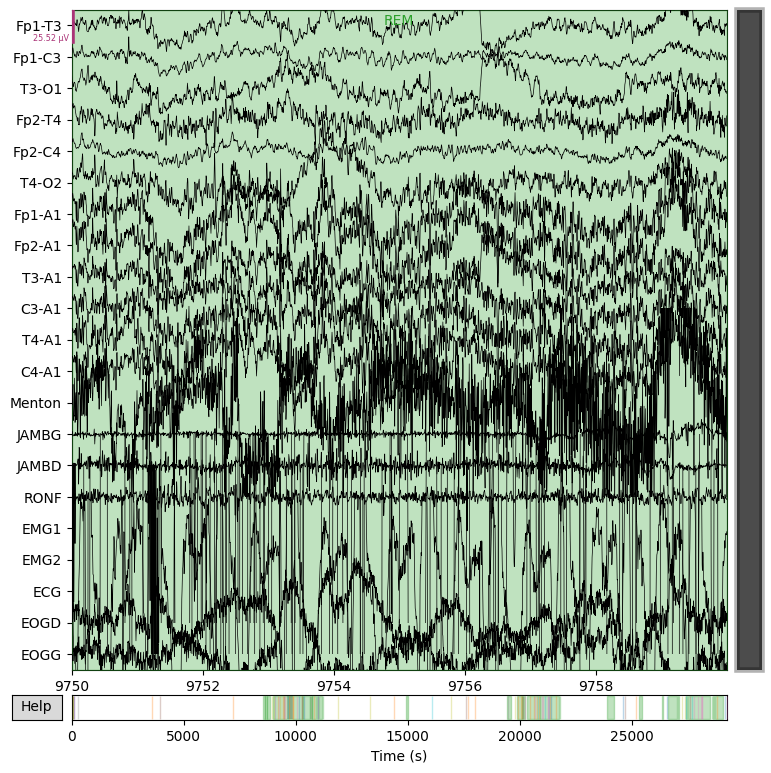

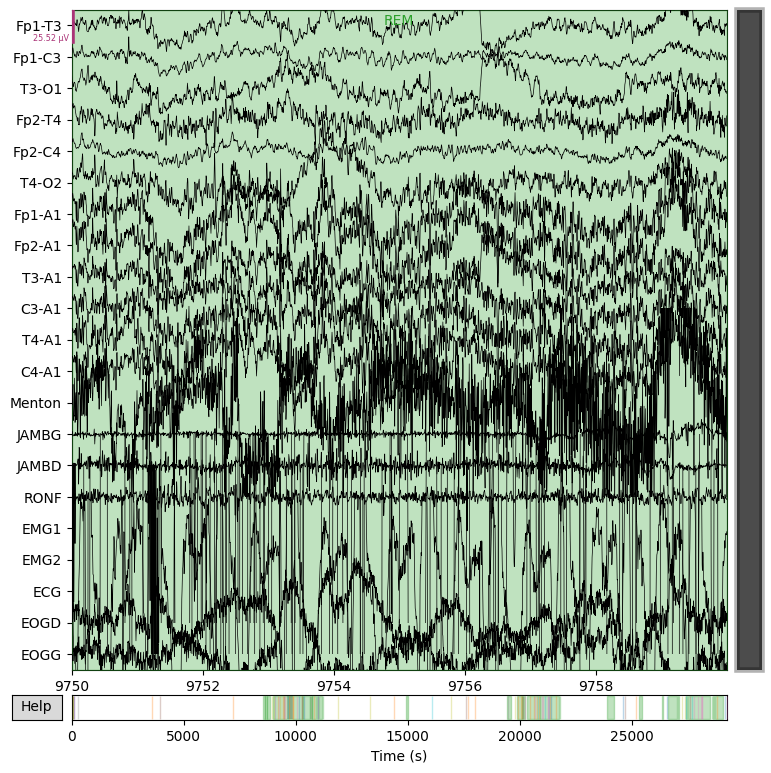

In [5]:
import mne
import os

patient_id = 'RJP148'
start_time = 9750
duration = 5
fif_path = f'../../data_raw_fif/siwar/{patient_id}/{patient_id}_raw.fif'
raw_fif = mne.io.read_raw_fif(fif_path, preload=True)
raw_fif.plot(n_channels=30, duration=10, start=start_time, scalings='auto', title='Raw EEG Data', show=True, block=True)

In [6]:
print(raw_fif.ch_names)

['Fp1-T3', 'Fp1-C3', 'T3-O1', 'Fp2-T4', 'Fp2-C4', 'T4-O2', 'Fp1-A1', 'Fp2-A1', 'T3-A1', 'C3-A1', 'T4-A1', 'C4-A1', 'Menton', 'JAMBG', 'JAMBD', 'RONF', 'EMG1', 'EMG2', 'ECG', 'EOGD', 'EOGG']


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


C:\Users\U1108091\AppData\Local\Temp\ipykernel_50496\1543626263.py:18: RuntimeWarning: The unit for channel(s) RONF has changed from V to NA.
  raw_fif.set_channel_types(channel_types)


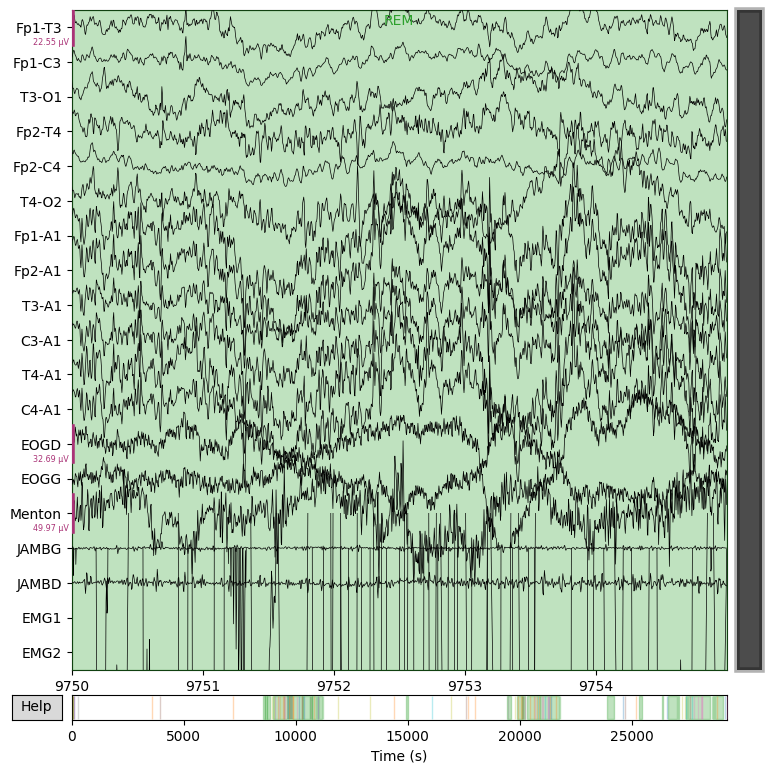

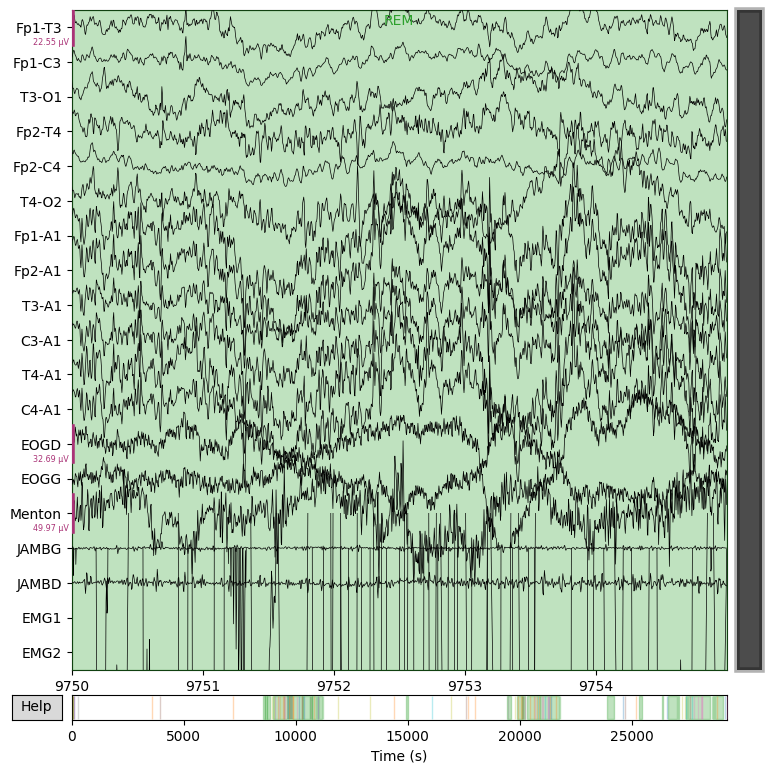

In [7]:
# Afficher les canaux EEG uniquement

# Reclassifier les canaux non-EEG
channel_types_candidates = {
    'Menton': 'emg',
    'JAMBG':  'emg',
    'JAMBD':  'emg',
    'RONF':   'misc',
    'EMG1':   'emg',
    'EMG2':   'emg',
    'ECG':    'ecg',
    'EOGD':   'eog',
    'EOGG':   'eog',
}
# Filtrer uniquement les canaux présents dans ce fichier
channel_types = {k: v for k, v in channel_types_candidates.items() if k in raw_fif.ch_names}

raw_fif.set_channel_types(channel_types)
raw_fif.pick_types(eeg=True, emg=True, eog=True, exclude='bads')

raw_fif.plot(
    n_channels=30,
    duration=5,
    start=start_time,
    scalings='auto',
    show=True,
    block=True
)

Extracting EDF parameters from ../../data_raw_edf/RJP148_raw.edf...


Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7483647  =      0.000 ... 29232.996 secs...


C:\Users\U1108091\AppData\Local\Temp\ipykernel_50496\1314493095.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(f'../../data_raw_edf/{patient_id}_raw.edf', preload=True)


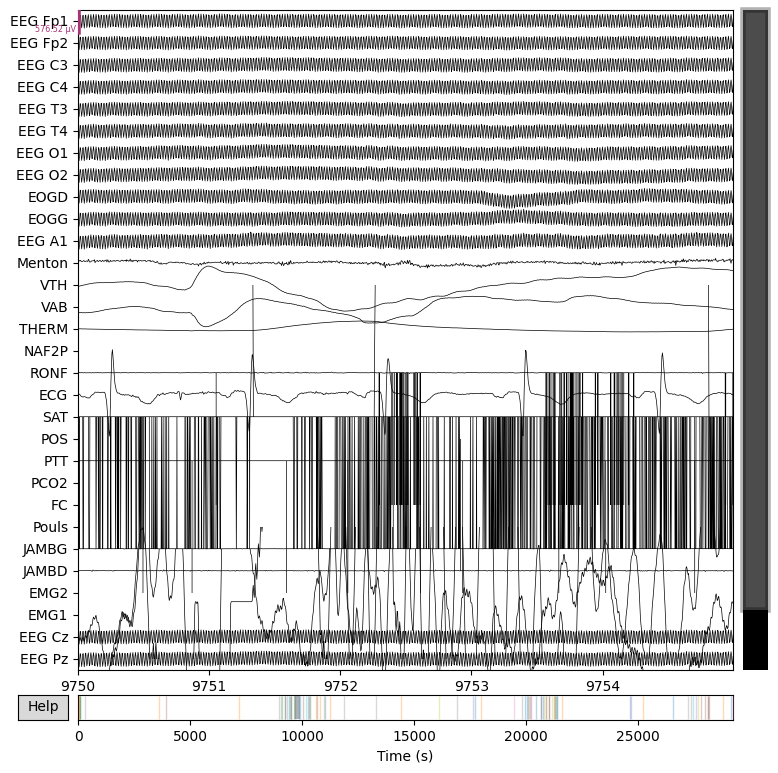

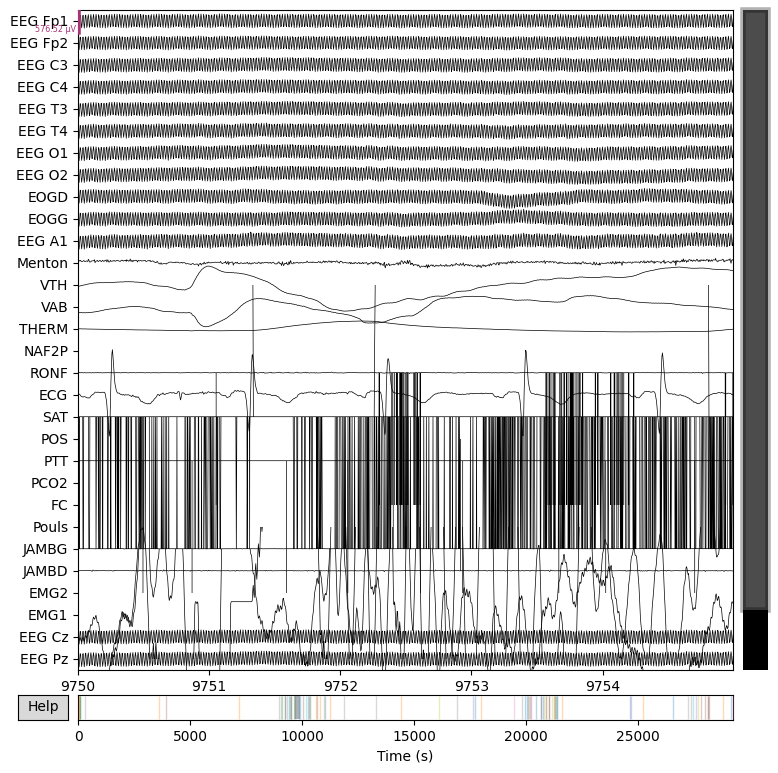

In [8]:
raw_edf = mne.io.read_raw_edf(f'../../data_raw_edf/{patient_id}_raw.edf', preload=True)
raw_edf.plot(n_channels=30, duration=5, start=start_time, scalings='auto', title='Raw EEG Data from EDF', show=True, block=True)

In [9]:
import mne
import matplotlib.pyplot as plt
import numpy as np


# --- Extraire le canal Menton de chaque fichier ---
# On vérifie d'abord le nom exact dans chaque fichier
print("FIF - canaux contenant 'Menton':", [c for c in raw_fif.ch_names if 'menton' in c.lower()])
print("EDF - canaux contenant 'Menton':", [c for c in raw_edf.ch_names if 'menton' in c.lower()])

FIF - canaux contenant 'Menton': ['Menton']
EDF - canaux contenant 'Menton': ['Menton']


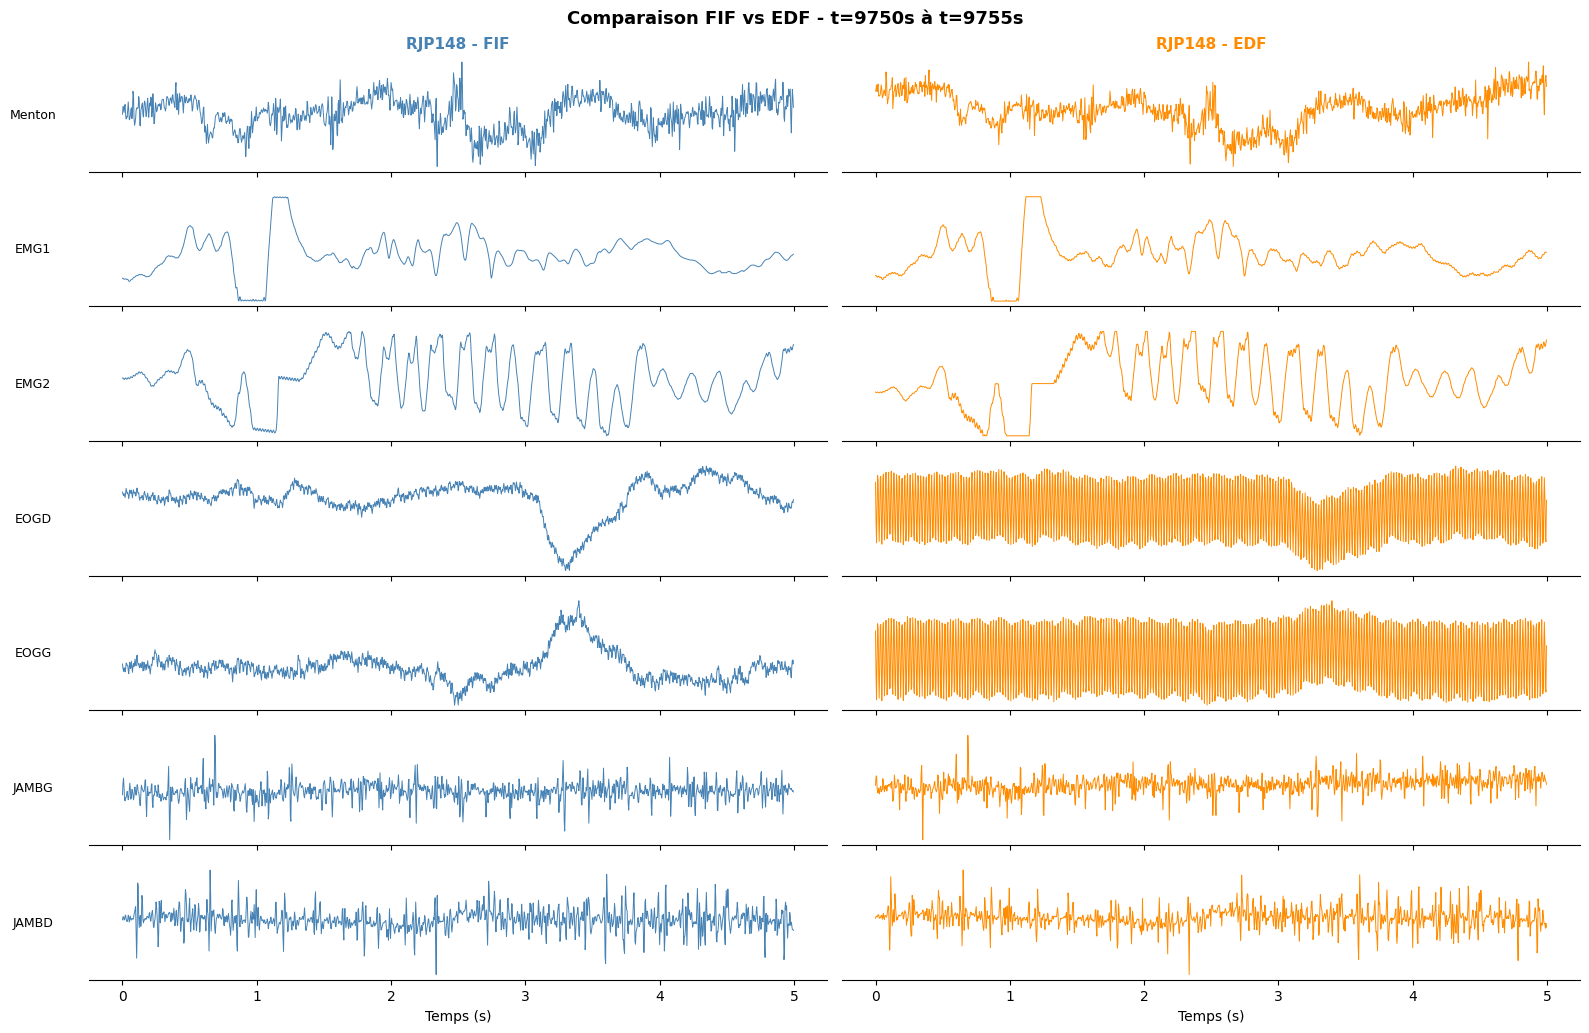

In [ ]:
import mne
import matplotlib.pyplot as plt
import numpy as np

# --- Paramètres ---
# commentaire à mettre !!!!!!!!!!!!!!
t_start = 9800
duration = 5   # (secondes)

# --- Canaux à afficher (adapte les noms selon tes print précédents) ---
canaux_fif = ['Menton', 'EMG1', 'EMG2', 'EOGD', 'EOGG']
canaux_edf = ['Menton', 'EMG1', 'EMG2', 'EOGD', 'EOGG']

def extract_channel(raw, ch_name, t_start, duration):
    idx = raw.ch_names.index(ch_name)
    sfreq = raw.info['sfreq']
    s_start = int(t_start * sfreq)
    s_end = int((t_start + duration) * sfreq)
    data, times = raw[idx, s_start:s_end]
    times_rel = times - times[0]  # temps relatif 0 → duration
    signal = data[0] * 1e6
    return times_rel, signal

def plot_stacked_comparison(raw_fif, raw_edf, canaux, t_start, duration):
    n = len(canaux)
    fig, axes = plt.subplots(
        n, 2,
        figsize=(16, n * 1.5),
        sharex=True
    )
    fig.suptitle(f'Comparaison FIF vs EDF - t={t_start}s à t={t_start+duration}s',
                 fontsize=13, fontweight='bold')

    # Headers
    axes[0, 0].set_title(f'{patient_id} - FIF', fontsize=11, color='steelblue', fontweight='bold')
    axes[0, 1].set_title(f'{patient_id} - EDF', fontsize=11, color='darkorange', fontweight='bold')

    for i, ch_name in enumerate(canaux):
        for col, (raw, color) in enumerate([(raw_fif, 'steelblue'), (raw_edf, 'darkorange')]):
            ax = axes[i, col]
            try:
                times, signal = extract_channel(raw, ch_name, t_start, duration)
                sig_norm = (signal - signal.mean()) / (signal.std() + 1e-9)
                ax.plot(times, sig_norm, color=color, linewidth=0.7)
            except ValueError:
                ax.text(0.5, 0.5, 'absent', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8, color='gray')

            ax.set_yticks([])
            ax.spines[['top', 'right', 'left']].set_visible(False)

            # Nom du canal uniquement sur la colonne gauche
            if col == 0:
                ax.set_ylabel(ch_name, rotation=0, labelpad=40,
                              fontsize=9, va='center')

    # Labels X uniquement sur la dernière ligne
    axes[-1, 0].set_xlabel('Temps (s)', fontsize=10)
    axes[-1, 1].set_xlabel('Temps (s)', fontsize=10)

    plt.tight_layout()
    plt.show()


# --- Canaux à comparer ---
canaux_communs = ['Menton', 'EMG1', 'EMG2', 'EOGD', 'EOGG', 'JAMBG', 'JAMBD']

plot_stacked_comparison(raw_fif, raw_edf, canaux_communs, t_start=start_time, duration=duration)



Opening raw data file ../../data_raw_fif/siwar/VA182/VA182_raw.fif...
Isotrak not found
    Range : 0 ... 7756543 =      0.000 ... 30298.996 secs
Ready.
Reading 0 ... 7756543  =      0.000 ... 30298.996 secs...
Extracting EDF parameters from ../../data_raw_edf/VA182_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7756543  =      0.000 ... 30298.996 secs...


C:\Users\U1108091\AppData\Local\Temp\ipykernel_50496\3494478944.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(f'../../data_raw_edf/{patient_id}_raw.edf', preload=True)


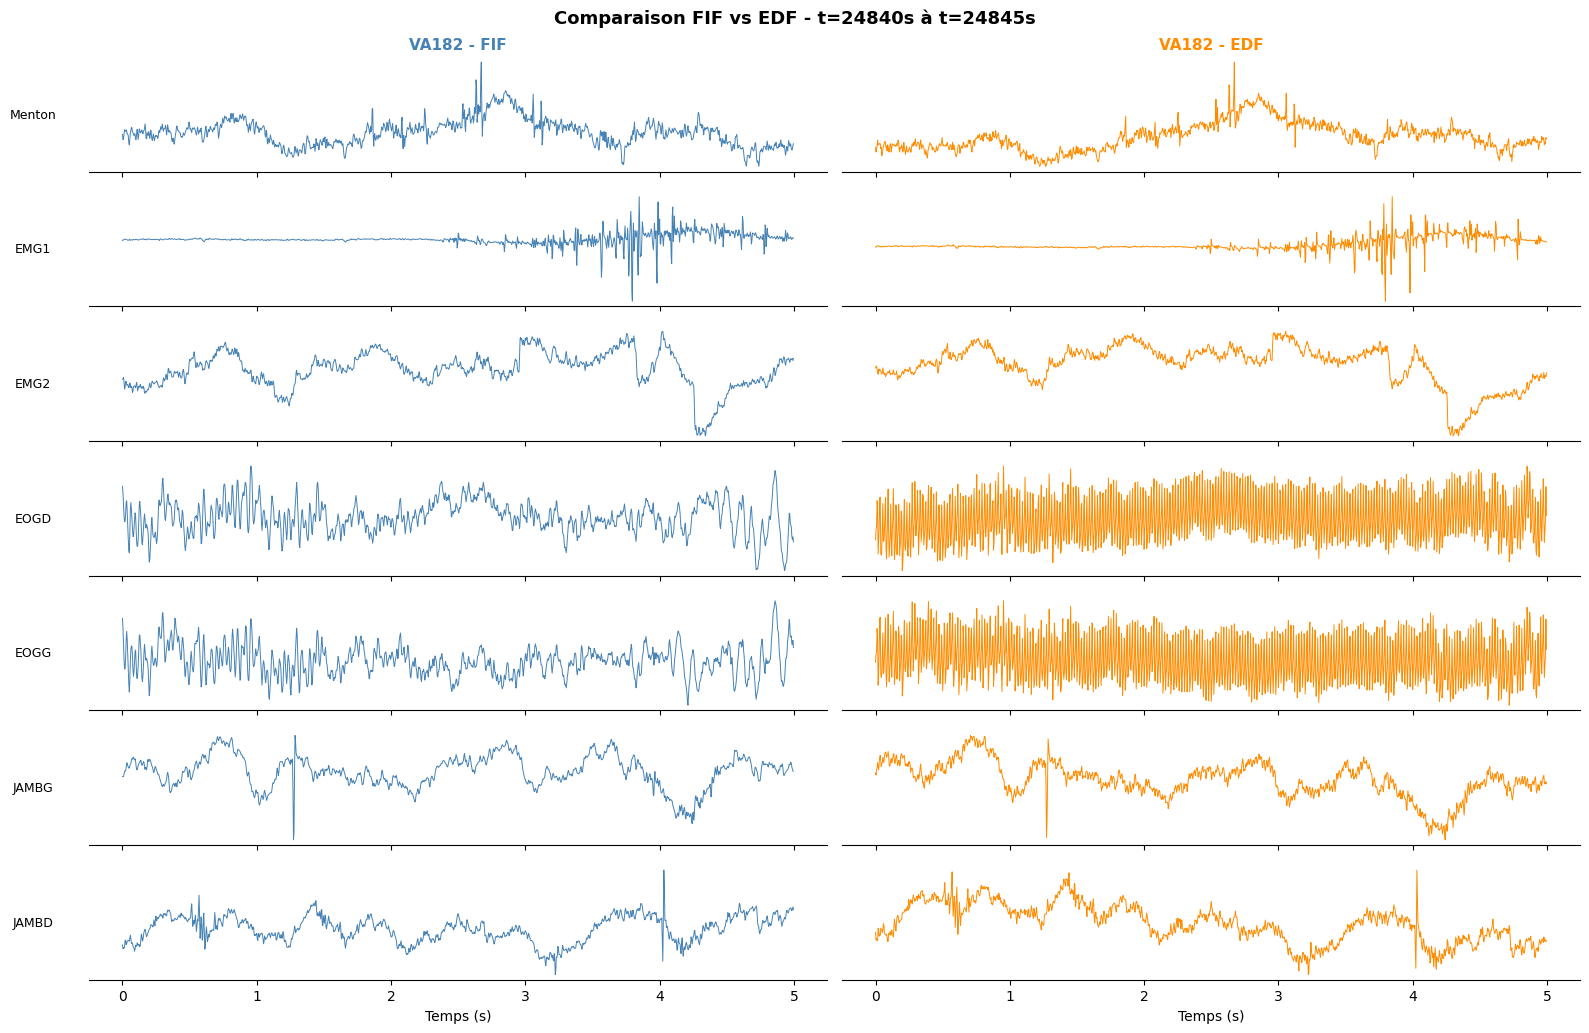

In [12]:
patient_id = 'VA182'
raw_fif = mne.io.read_raw_fif(f'../../data_raw_fif/siwar/{patient_id}/{patient_id}_raw.fif', preload=True)
raw_edf = mne.io.read_raw_edf(f'../../data_raw_edf/{patient_id}_raw.edf', preload=True)
plot_stacked_comparison(raw_fif, raw_edf, canaux_communs, t_start=24840, duration=duration)

## Avec enveloppe RMS pour mieux visualiser les différences

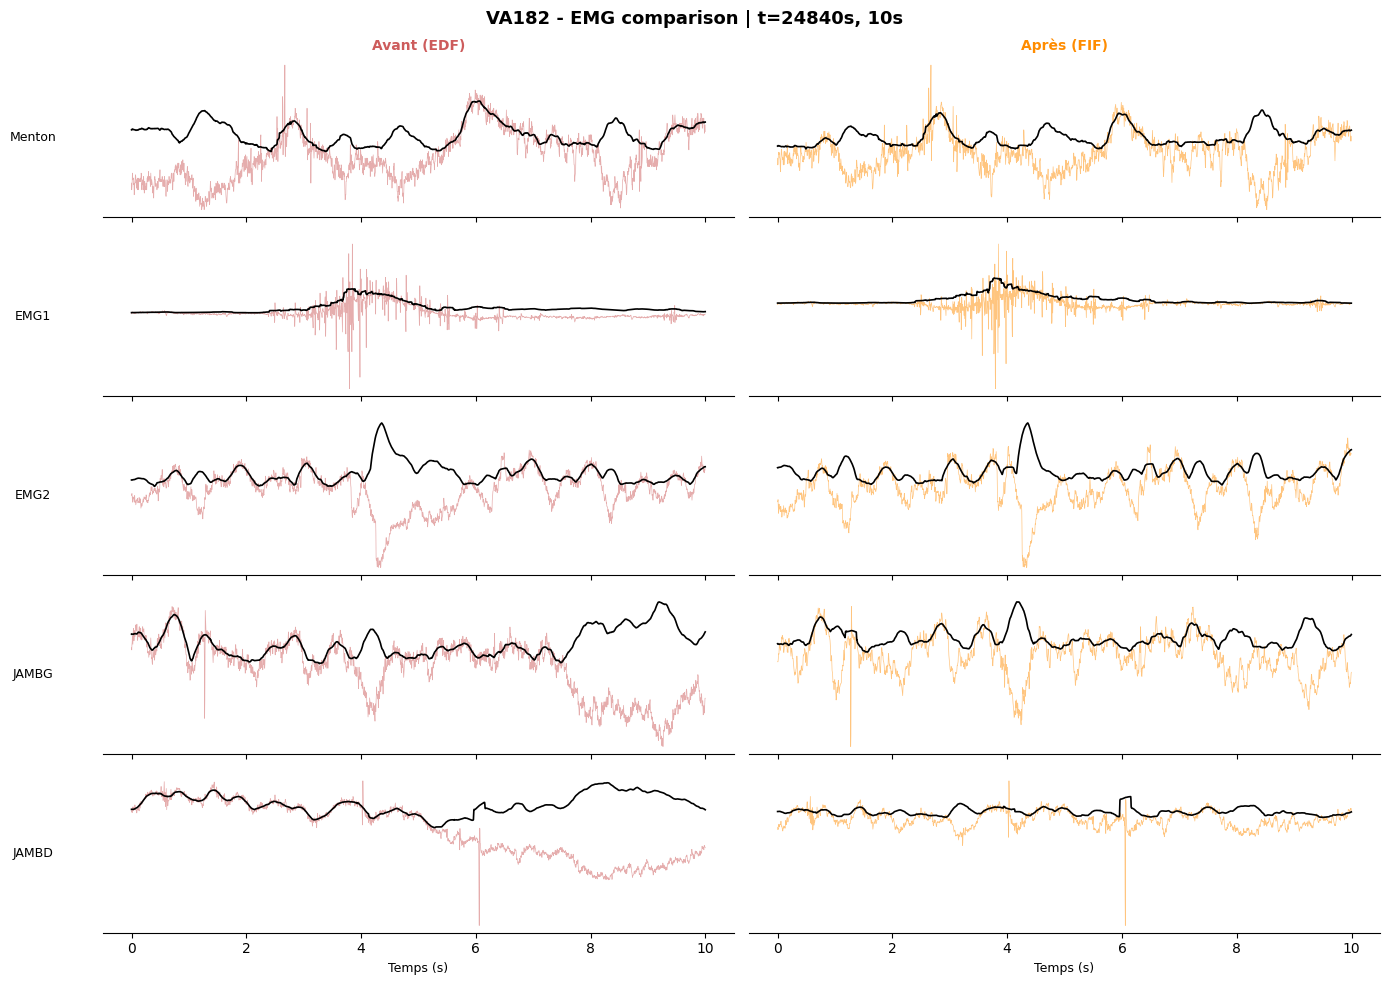

In [ ]:
def plot_preprocessing_comparison(raw_before, raw_after,
                                   emg_channels_before, emg_channels_after,
                                   t_start, duration, patient_id=''):

    sfreq_before = raw_before.info['sfreq']
    sfreq_after  = raw_after.info['sfreq']

    def extract(raw, ch_name, sfreq):
        idx = raw.ch_names.index(ch_name)
        s0, s1 = int(t_start * sfreq), int((t_start + duration) * sfreq)
        data, times = raw[idx, s0:s1]
        return times - times[0], data[0] * 1e6

    def rms_envelope(signal, sfreq, window_s=0.1):
        win = int(window_s * sfreq)
        return np.array([
            np.sqrt(np.mean(signal[max(0, i-win):i+win]**2))
            for i in range(len(signal))
        ])

    n_emg = max(len(emg_channels_before), len(emg_channels_after))

    fig, axes = plt.subplots(n_emg, 2, figsize=(14, n_emg * 2), sharex=True)
    if n_emg == 1:
        axes = np.array([axes])

    fig.suptitle(f'{patient_id} - EMG comparison | t={t_start}s, {duration}s',
                 fontsize=13, fontweight='bold')

    axes[0, 0].set_title('Avant (EDF)', fontsize=10, color='indianred', fontweight='bold')
    axes[0, 1].set_title('Après (FIF)', fontsize=10, color='darkorange', fontweight='bold')

    for j in range(n_emg):
        for col, (raw, channels, sfreq, color) in enumerate([
            (raw_before, emg_channels_before, sfreq_before, 'indianred'),
            (raw_after,  emg_channels_after,  sfreq_after,  'darkorange'),
        ]):
            ax = axes[j, col]
            ax.set_yticks([])
            ax.spines[['top', 'right', 'left']].set_visible(False)

            if j < len(channels):
                ch = channels[j]
                try:
                    t, s = extract(raw, ch, sfreq)
                    s_norm = (s - s.mean()) / (s.std() + 1e-9)
                    env = rms_envelope(s_norm, sfreq)
                    ax.plot(t, s_norm, color=color, linewidth=0.5, alpha=0.5)
                    ax.plot(t, env, color='black', linewidth=1.2)
                except ValueError:
                    ax.text(0.5, 0.5, 'absent', ha='center', va='center',
                            transform=ax.transAxes, fontsize=8, color='gray')
            else:
                ax.axis('off')

            if col == 0 and j < len(emg_channels_before):
                ax.set_ylabel(emg_channels_before[j], rotation=0,
                              labelpad=50, fontsize=9, va='center')

    axes[-1, 0].set_xlabel('Temps (s)', fontsize=9)
    axes[-1, 1].set_xlabel('Temps (s)', fontsize=9)

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/{patient_id}_emg_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


# ── Appel ─────────────────────────────────────────────────────────────
plot_preprocessing_comparison(
    raw_before=raw_edf,
    raw_after=raw_fif,
    emg_channels_before=['Menton', 'EMG1', 'EMG2', 'JAMBG', 'JAMBD'],
    emg_channels_after= ['Menton', 'EMG1', 'EMG2', 'JAMBG', 'JAMBD'],
    t_start=24840,
    duration=10,
    patient_id=patient_id
)

## Artefacts : 

#### Artéfacts détectés dans le fichier .fif

In [2]:
import os
import mne
import pandas as pd

pat_ID = "BA171"
raw_fif = mne.io.read_raw_fif(
    os.path.join('../../data_raw_fif', f'{pat_ID}_raw.fif'),
    preload=False
)

print(raw_fif.annotations)
print()

ann_df = raw_fif.annotations.to_data_frame()
print(ann_df['description'].value_counts())

Opening raw data file ../../data_raw_fif\BA171_raw.fif...
Isotrak not found
    Range : 0 ... 6999551 =      0.000 ... 27341.996 secs
Ready.
<Annotations | 131 segments: <IMPEDANCE> (1), ARTEFACT (94), ARYTHMIE (1), ...>

description
ARTEFACT                                       94
REM                                             8
Fin                                             7
TCSP                                            4
<IMPEDANCE>                                     1
IDENTITE OK                                     1
TEST YEUX OK                                    1
TEST MENTON OK                                  1
TEST NAF OK                                     1
TEST APNEE OK                                   1
TEST PHONO OK                                   1
TEST JAMBIER DT  OK                             1
TEST JAMBIER DT OK                              1
TEST JAMBIER G OK                               1
TEST RADIAL DT EMG2 OK                          1
TEST RADIAL G EM

#### Vérification des annotations des données brutes (.edf)

In [ ]:
import mne
import pandas as pd

pat_ID = "BA171"

# EDF
raw_edf = mne.io.read_raw_edf(
    f'../../data_raw_edf/{pat_ID}_raw.edf',
    preload=False
)

print("=== ANNOTATIONS EDF ===")
print(raw_edf.annotations)
print()
ann_edf = raw_edf.annotations.to_data_frame()
print(ann_edf['description'].value_counts())

print("\n=== ANNOTATIONS FIF ===")
raw_fif = mne.io.read_raw_fif(
    f'../../data_raw_fif/{pat_ID}_raw.fif',
    preload=False
)
print(raw_fif.annotations)
print()
ann_fif = raw_fif.annotations.to_data_frame()
print(ann_fif['description'].value_counts())

Extracting EDF parameters from ../../data_raw_edf/BA171_raw.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\U1108091\AppData\Local\Temp\ipykernel_8140\238729883.py:7: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_edf = mne.io.read_raw_edf(


=== ANNOTATIONS EDF ===
<Annotations | 29 segments: <IMPEDANCE> (1), ARYTHMIE (1), Fin (7), ...>

description
Fin                                            7
TCSP                                           4
<IMPEDANCE>                                    1
IDENTITE OK                                    1
TEST YEUX OK                                   1
TEST MENTON OK                                 1
TEST NAF OK                                    1
TEST APNEE OK                                  1
TEST PHONO OK                                  1
TEST JAMBIER DT  OK                            1
TEST JAMBIER DT OK                             1
TEST JAMBIER G OK                              1
TEST RADIAL DT EMG2 OK                         1
TEST RADIAL G EMG1 OK                          1
TREMBLEMENT MENTON  VISIBLE SUR TRACE AUSSI    1
Lumières éteintes                              1
ARYTHMIE                                       1
therm vue                                      1
signal T

#### Liste des artéfacts et leur fenetre de détection

In [6]:
import mne

pat_ID = "BA171"
raw = mne.io.read_raw_fif(f"../../data_raw_fif/{pat_ID}_raw.fif", preload=False)

# Filtrer uniquement les annotations ARTEFACT
artefact_idx = [i for i, desc in enumerate(raw.annotations.description) if desc == "ARTEFACT"]

onsets = raw.annotations.onset[artefact_idx]
durations = raw.annotations.duration[artefact_idx]

print(f"Nombre de segments ARTEFACT : {len(onsets)}")
for onset, dur in zip(onsets, durations):
    print(f"  {onset:.1f}s -> {onset + dur:.1f}s (durée : {dur:.1f}s)")

Opening raw data file ../../data_raw_fif/BA171_raw.fif...
Isotrak not found
    Range : 0 ... 6999551 =      0.000 ... 27341.996 secs
Ready.
Nombre de segments ARTEFACT : 94
  3280.0s -> 3288.0s (durée : 8.0s)
  4152.0s -> 4160.0s (durée : 8.0s)
  5312.0s -> 5316.0s (durée : 4.0s)
  5320.0s -> 5324.0s (durée : 4.0s)
  5356.0s -> 5364.0s (durée : 8.0s)
  5460.0s -> 5464.0s (durée : 4.0s)
  5468.0s -> 5532.0s (durée : 64.0s)
  5536.0s -> 5596.0s (durée : 60.0s)
  5620.0s -> 5640.0s (durée : 20.0s)
  5644.0s -> 5648.0s (durée : 4.0s)
  5712.0s -> 5716.0s (durée : 4.0s)
  5720.0s -> 5728.0s (durée : 8.0s)
  5752.0s -> 5756.0s (durée : 4.0s)
  5760.0s -> 5772.0s (durée : 12.0s)
  5776.0s -> 5780.0s (durée : 4.0s)
  5792.0s -> 5852.0s (durée : 60.0s)
  5864.0s -> 5872.0s (durée : 8.0s)
  5876.0s -> 5880.0s (durée : 4.0s)
  5884.0s -> 5888.0s (durée : 4.0s)
  5944.0s -> 5948.0s (durée : 4.0s)
  5952.0s -> 5960.0s (durée : 8.0s)
  5972.0s -> 5980.0s (durée : 8.0s)
  5984.0s -> 5988.0s (durée :

#### Visualisation des artéfacts

In [9]:
%matplotlib inline

Opening raw data file ../../data_raw_fif/BA171_raw.fif...
Isotrak not found
    Range : 0 ... 6999551 =      0.000 ... 27341.996 secs
Ready.
Reading 0 ... 6999551  =      0.000 ... 27341.996 secs...
Nombre de segments ARTEFACT : 94


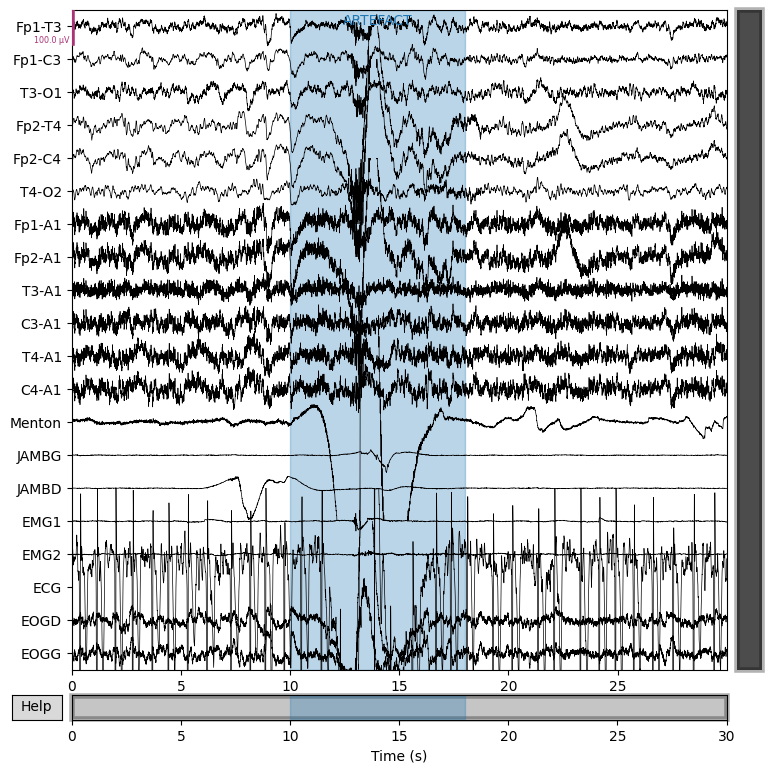

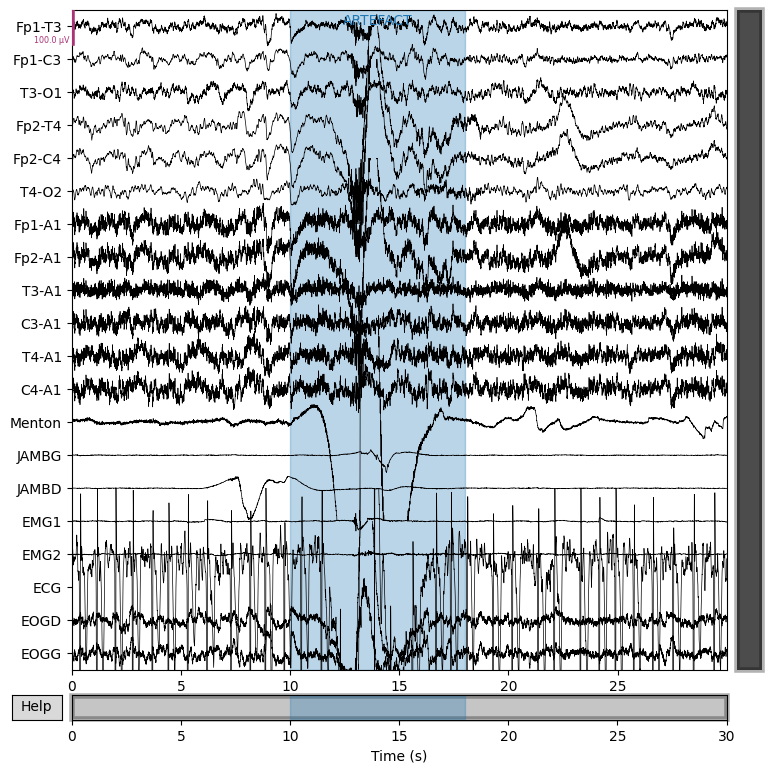

In [ ]:
import mne
import matplotlib.pyplot as plt

# === Chargement du fichier ===
pat_ID = "BA171"
raw = mne.io.read_raw_fif(f"../../data_raw_fif/{pat_ID}_raw.fif", preload=True)

# === Extraction des annotations ARTEFACT ===
artefact_idx = [i for i, desc in enumerate(raw.annotations.description) if desc == "ARTEFACT"]
onsets = raw.annotations.onset[artefact_idx]
durations = raw.annotations.duration[artefact_idx]

print(f"Nombre de segments ARTEFACT : {len(onsets)}")

# === Paramètres d'affichage ===
padding = 2.0

tmin = 3270
tmax = 3300
raw_segment = raw.copy().crop(tmin=tmin, tmax=tmax)
raw_segment.drop_channels(["RONF"])  # exclusion du canal RONF

scalings = dict(
    eeg=50e-6,
    emg=100e-6,
    eog=150e-6,
    ecg=500e-6,
)

raw_segment.plot(
    duration=tmax - tmin,
    n_channels=len(raw_segment.ch_names),  # mis à jour après drop_channels
    scalings=scalings,
    title=f"Artefact ({pat_ID})- {tmin}s à {tmax}s",
    picks=["eeg", "emg", "eog"],
)